# Imports and Set Up

Set correct working directory:

In [1]:
import os 
os.chdir('/rds/general/user/eso18/home/mmvmvae/')

Package imports:

In [2]:
import torch
import hydra
import yaml
from omegaconf import OmegaConf
from hydra.core.config_store import ConfigStore
from hydra import initialize, compose
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.utilities.model_summary.model_summary import ModelSummary
from matplotlib import colormaps as cm
torch.set_float32_matmul_precision('high')

Module imports:

In [3]:
from utils import dataset
from utils.scMNCDataset import scMNC
# experiment configs 
from config.ExperimentConfig import ExperimentConfig
from config.ExperimentConfig import LogConfig
from config.ExperimentConfig import EvalConfig
# model configs
from config.ModelConfig import JointModelConfig
from config.ModelConfig import MixedPriorModelConfig
from config.ModelConfig import UnimodalModelConfig
from config.ModelConfig import JointPriorModelConfig
# dataset configs
from config.DatasetConfig import PMtranslatedData75Config
from config.DatasetConfig import CelebADataConfig
from config.DatasetConfig import scMNCDataConfig
# models
from mv_vaes.mv_joint_vae import MVJointVAE as MVJointVAE
from mv_vaes.mv_unimodal_vae import MVunimodalVAE as MVunimodalVAE
from mv_vaes.mv_mixedprior_vae import MVMixedPriorVAE as MVMixedPriorVAE
from mv_vaes.mv_jointprior_vae import MVJointPriorVAE as MVJointPriorVAE

Initialise configuration storage:

In [4]:
cs = ConfigStore.instance()
cs.store(group="log", name="log", node=LogConfig)
cs.store(group="model", name="joint", node=JointModelConfig)
cs.store(group="model", name="mixedprior", node=MixedPriorModelConfig)
cs.store(group="model", name="jointprior", node=JointPriorModelConfig)
cs.store(group="model", name="unimodal", node=UnimodalModelConfig)
cs.store(group="eval", name="eval", node=EvalConfig)
cs.store(group="dataset", name="PMtranslated75", node=PMtranslatedData75Config)
cs.store(group="dataset", name="CelebA", node=CelebADataConfig)
cs.store(group="dataset", name="scMNC", node=scMNCDataConfig)
cs.store(name="base_config", node=ExperimentConfig)

# Application of model

Specify the model to run and the data to run on etc. 

In [5]:
with initialize(version_base=None, config_path="config", job_name="application"):
    cfg = compose(config_name="config",
                  overrides=[
                      "dataset=scMNC", # one of: CelebA, PMtranslated75, scMNC
                      "model=jointprior", #one of: jointprior, mixedprior, joint, unimodal
                      "dataset.num_workers=1",# 
                      "model.device=cpu", # if using cpu, otherwise cuda or device
                      "model.batch_size=128", # default is 128
                      "model.epochs=100",
                      "model.early_stop=True",
                      "log.val_freq=1",
                      "log.img_plotting_frequency=10000000",
                      "log.downstream_logging_frequency=1",
                      "log.coherence_logging_frequency=1",
                      "log.fid_logging_frequency=1",
                  ])
if cfg.model.device != "cuda":
        cfg.dataset.dir_clf = cfg.dataset.dir_clf + "_cpu"

In [6]:
train_loader, train_dst, val_loader, _= dataset.get_dataset(cfg)

## Not used I don't think

In [18]:
training = True
data_loader = torch.utils.data.DataLoader(
            train_dst,
            batch_size=3654 if training else 731,
            shuffle=False,
            num_workers=cfg.dataset.num_workers,
            drop_last=False,
        )
batch = next(iter(data_loader))
exp_data = batch[0]["exp"].numpy() # expression data
feat_data = batch[0]["feat"].numpy() # feature data
labels = batch[1].numpy() # tensor of labels

# CelebA

In [8]:
batch1 = next(iter(train_loader))

In [13]:
batch1[0]['img'].min()

tensor(0.)

In [10]:
images = batch1[0]['img']
text = batch1[0]['text']

In [24]:
text_sums = np.zeros(128)
starts = np.zeros(128)
for i in range(128):
    text_ex = text[i].detach().clone()
    text_ex[:, 39] = 0
    text_sums[i] = text_ex.sum().detach().numpy()
    starts[i] = text_ex.sum(axis=1).argmax().detach().numpy()

In [12]:
import numpy as np
sums = np.array([sums.numpy() for sums in text_sums])

In [26]:
import matplotlib.pyplot as plt

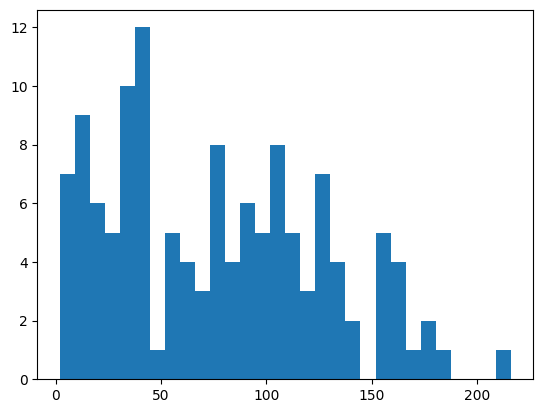

In [33]:
plt.hist(starts, bins=30)
plt.show()

In [7]:
import pandas as pd 
df_text = pd.read_csv("data/CelebA/list_attr_text_256_False_True_celeba.csv")

In [69]:
df_part = pd.read_csv("data/CelebA/list_eval_partition.csv")
df_attributes = pd.read_csv("data/CelebA/list_attr_celeba.csv")
df_attributes = df_attributes[(df_part['partition'] == 2)]
df_attributes = df_attributes.drop(["image_id"], axis=1)

In [17]:
# frequency plot graph
attributes = df_attributes.copy()
for column in attributes.columns[1:]:
    attributes[column] = attributes[column].map({1 : 1, -1: 0})
freq_attr = attribtues.sum(axis=0)
s_sorted = (freq_attr/(freq_attr.sum())).sort_values()                   

In [72]:
# string length
attributes = df_attributes.copy()
for column in attributes.columns[1:]:
    attributes[column] = attributes[column].map({1 : len(column), -1: 0})
length = attributes.sum(axis=1)   

In [100]:
# no attributes length
attributes = df_attributes.copy()
for column in attributes.columns[1:]:
    attributes[column] = attributes[column].map({1 : 1, -1: 0})
no_attr = attributes.sum(axis=1)   

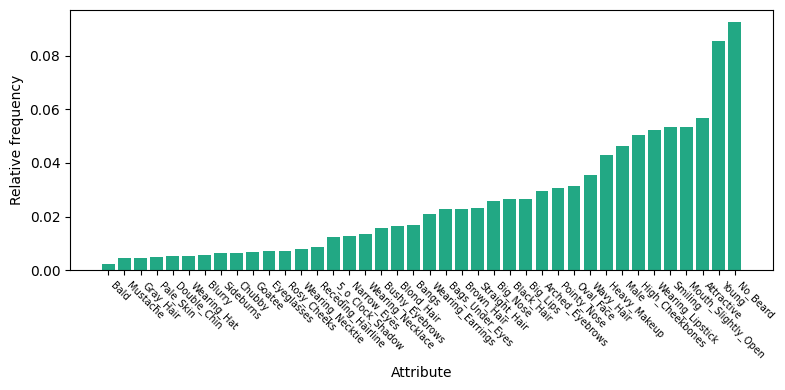

In [98]:
cmap = cm.get_cmap('viridis')
color_pos = 0.6
figsize = (8, 4)
xlabel = 'Attribute'
ylabel = 'Relative frequency'
color = cmap(color_pos)                      # RGBA tuple for a single color

fig, ax = plt.subplots(figsize=figsize)
ax.bar(range(len(s_sorted)), s_sorted.values, color=color)
ax.set_xticks(range(len(s_sorted)))
ax.set_xticklabels(s_sorted.index, rotation=315, ha='left', fontsize=7)  # 45° labels
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
plt.tight_layout()
plt.savefig("data/CelebA/attribute_frequencies.png")

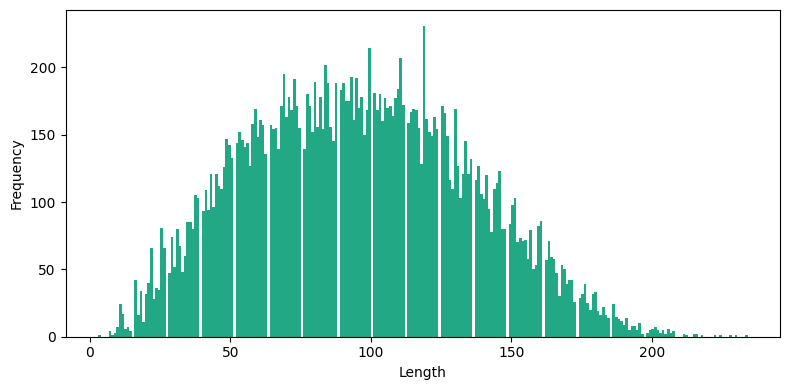

In [110]:
xlabel = 'Length'
#xlabel = r"length of $s'$"
ylabel = "Frequency"
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize=figsize)
ax.hist(length, bins=250, color=color)
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
plt.tight_layout()
plt.savefig("data/CelebA/string_lengths.png")

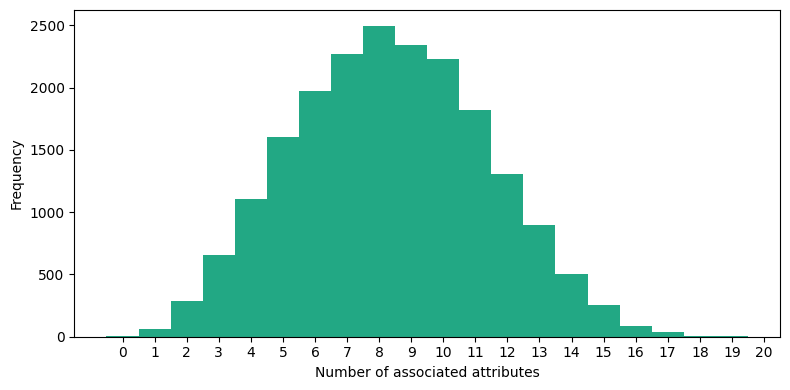

In [107]:
import numpy as np
xlabel = 'Number of associated attributes'
#xlabel = r"length of $s'$"
ylabel = "Frequency"
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize=figsize)
bins = np.arange(0, no_attr.max() + 1.5) - 0.5
ax.hist(no_attr, bins=bins, color=color)
ax.set_xlabel(xlabel)
ax.set_xticks([i +0.5 for i in bins])
# ax.set_xticklabels(s_sorted.index, rotation=315, ha='left', fontsize=7)  # 45° labels
ax.set_ylabel(ylabel)
plt.tight_layout()
plt.savefig("data/CelebA/no_attrs.png")

In [88]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": ""
})

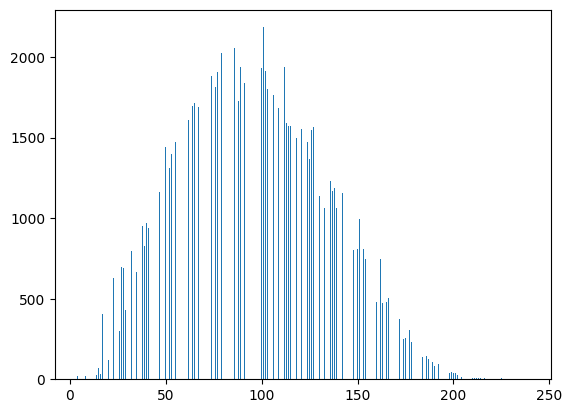

In [80]:
plt.hist(total_length, bins=1000)
plt.show()

In [82]:
total_length.min()

4

In [23]:
text_sums = np.zeros(128)

In [69]:
df_text['text'][3].sum

'*********************attractive, no beard, pointy nose, straight hair, wearing earrings, wearing lipstick, wearing necklace, young******************************************************************************************************************************'

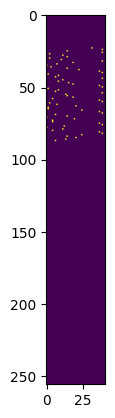

In [87]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
im = ax.imshow(text_ex)

# scMNC

Load the dataset and create evaluation test set.

In [10]:
train_loader, train_dst, val_loader, _= dataset.get_dataset(cfg)
# training_dst = dataset.get_full_dataset(cfg, training=False)
test_dst = dataset.get_full_dataset(cfg, training=False)

In [8]:
folder_path = "as"
folder_path + "/runs"

'as/runs'

Define the model and trainer.

In [11]:
model = MVJointPriorVAE(cfg)
early_stopping = EarlyStopping(monitor="val/loss/loss_rec", mode="min")
trainer = pl.Trainer(
        max_epochs=cfg.model.epochs, # default is 400
        devices=cfg.dataset.num_workers, # default is 8
        accelerator="gpu" if cfg.model.device == "cuda" else cfg.model.device,
        check_val_every_n_epoch=cfg.log.val_freq, # default is 50
        log_every_n_steps=22 if cfg.dataset == "scMNC" else 50,
        deterministic=True,
        callbacks=[early_stopping] if cfg.model.early_stop else [],
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/rds/general/user/eso18/home/anaconda3/envs/mvvae/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:67: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Train model.

In [12]:
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.eval() # set model to evaluation


  | Name       | Type       | Params
------------------------------------------
0 | encoders   | ModuleList | 7.5 M 
1 | decoders   | ModuleList | 7.1 M 
2 | cov_mat    | ModuleList | 65.8 K
3 | transforms | Compose    | 0     
------------------------------------------
14.7 M    Trainable params
0         Non-trainable params
14.7 M    Total params
58.784    Total estimated model params size (MB)


/rds/general/user/eso18/home/anaconda3/envs/mvvae/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:293: The number of training batches (22) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 22/22 [00:06<00:00,  3.58it/s, v_num=14]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 22/22 [00:05<00:00,  3.76it/s, v_num=14]      
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 22/22 [00:06<00:00,  3.50it/s, v_num=14]      
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 22/22 [00:05<00:00,  3.72it/s, v_num=14]      
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 22/22 [00:05<00:00,  3.71it/s, v_num=14]      
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 22/22 [00:06<00:00,  3.58it/s, v_num=14]      
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 22/22 [00:06<00:00,  3.58it/s, v_num=14]      
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 22/22 [00:06<00:00,  3.55it/s, v_num=14]      
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 22/22 [00:05<00:00,  3.78it/s, v_num=14]      
idati

MVJointPriorVAE(
  (encoders): ModuleList(
    (0): scEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=1302, out_features=2604, bias=True)
        (1): BatchNorm1d(2604, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
        (3): Linear(in_features=2604, out_features=1302, bias=True)
        (4): BatchNorm1d(1302, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.01)
      )
      (mu): Linear(in_features=1302, out_features=256, bias=True)
      (logvar): Linear(in_features=1302, out_features=256, bias=True)
    )
    (1): scEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=39, out_features=78, bias=True)
        (1): BatchNorm1d(78, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
        (3): Linear(in_features=78, out_features=39, bias=True)
        (4): BatchNorm1d(39, e

Alternatively, run the following cell to reload a previous run:

In [22]:
test_dst = dataset.get_full_dataset(cfg, training=False)

In [121]:
checkpoint = "./lightning_logs/version_13/checkpoints/epoch=46-step=4277.ckpt"
model = MVJointPriorVAE.load_from_checkpoint(checkpoint, cfg=cfg)

Evaluate model on full test set.

In [ ]:
test_dst = dataset.get_full_dataset(cfg, training=False)

In [24]:
batch_out = model.forward(test_dst.batch)
exp_out = batch_out[0]["exp"][0].detach().numpy()
feat_out = batch_out[0]["feat"][0].detach().numpy()
exp_latent_mean = batch_out[1]["exp"][0].detach().numpy()
exp_latent_logvar = batch_out[1]["exp"][1].detach().numpy()
feat_latent_mean = batch_out[1]["feat"][0].detach().numpy()
feat_latent_logvar = batch_out[1]["feat"][1].detach().numpy()

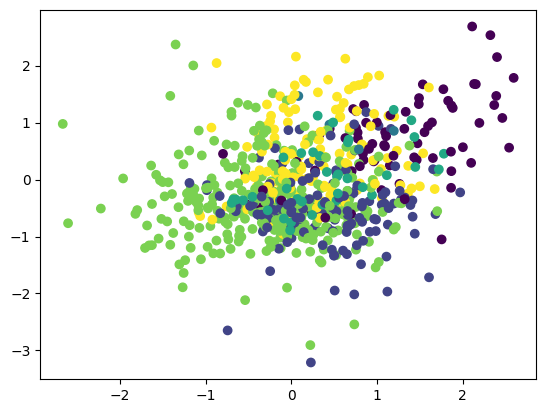

In [51]:
labels = test_dst.labels
X = exp_latent_mean
# X_pca = pca.fit_transform(X)
plt.scatter(X[:,0], X[:,1], c=test_dst.labels)
plt.show()

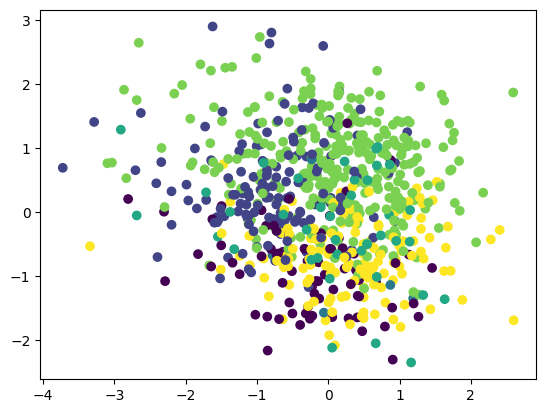

In [50]:
labels = test_dst.labels
X = feat_latent_mean
# X_pca = pca.fit_transform(X)
plt.scatter(X[:,0], X[:,1], c=test_dst.labels)
plt.show()

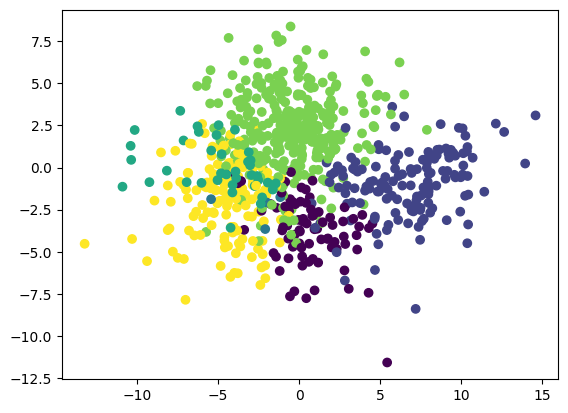

In [44]:
labels = test_dst.labels
X = exp_latent_mean
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1], c=test_dst.labels)
plt.show()

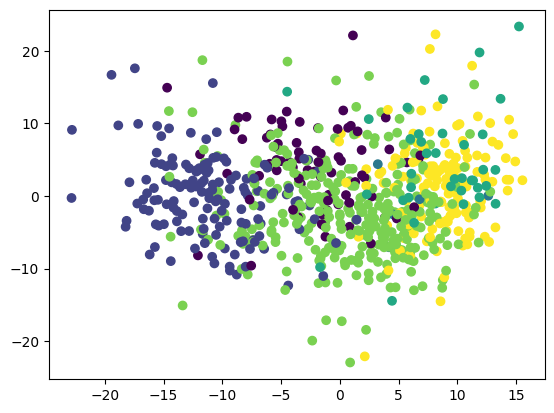

In [45]:
labels = test_dst.labels
X = feat_latent_mean
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1], c=test_dst.labels)
plt.show()

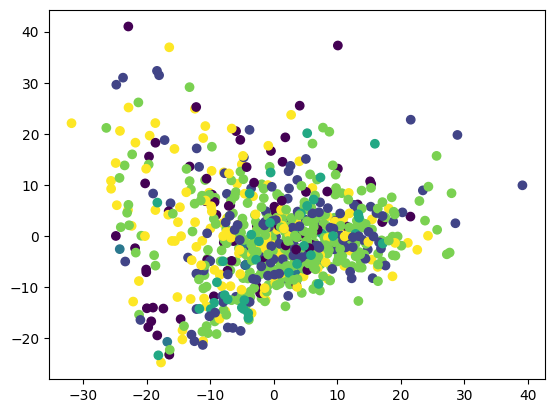

In [59]:
X = test_dst.exp_data
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1], c=test_dst.labels)
plt.show()

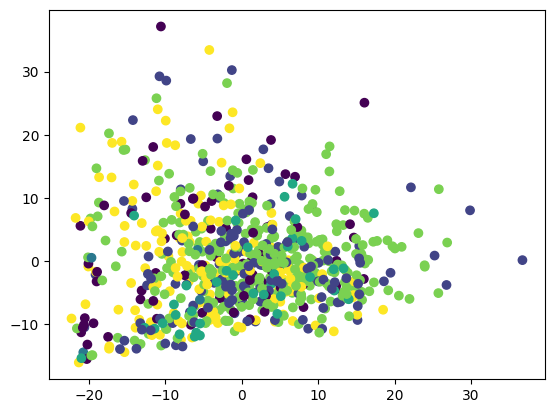

In [60]:
X = exp_out
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1], c=test_dst.labels)
plt.show()

In [55]:
feat_out.shape

(731, 39)

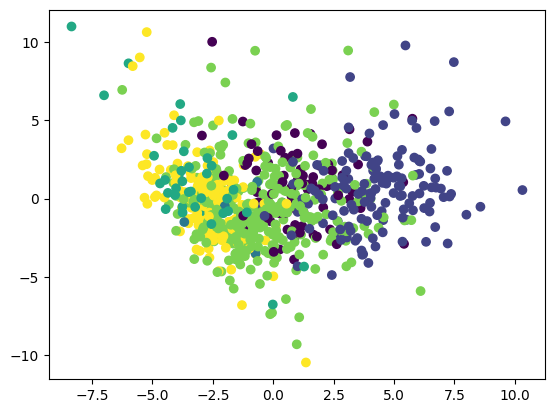

In [57]:
X = test_dst.feat_data
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1], c=test_dst.labels)
plt.show()

In [28]:
pca = PCA(n_components=10)
pca.fit(exp_latent_mean)

,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [26]:
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [147]:
batch[0]["exp"]

tensor([[-0.3066, -0.4149, -0.0900,  ..., -0.5587, -0.5040, -0.1372],
        [-0.3066, -0.4149, -0.0900,  ..., -0.8819, -0.5040, -0.1372],
        [-0.3066, -0.4149, -0.0900,  ...,  0.3408, -0.5040, -0.1372],
        ...,
        [-0.3066,  0.0708, -0.0900,  ..., -0.5025, -0.5040, -0.1372],
        [-0.3066, -0.4149, -0.0900,  ..., -0.7695,  1.2726, -0.1372],
        [-0.3066, -0.4149, -0.0900,  ..., -0.1019,  0.0411, -0.1372]])

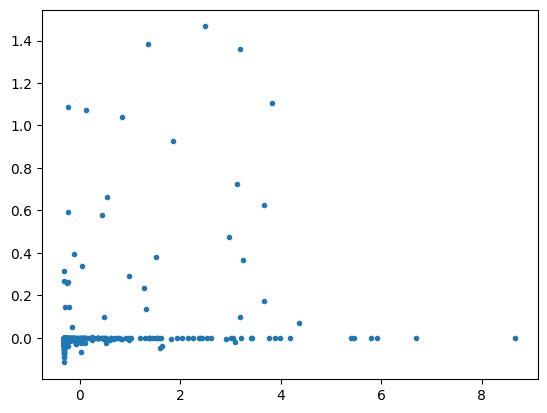

In [150]:
plt.plot(batch[0]["exp"][:,0], exp_out[:,0], '.')
plt.show()

In [164]:
import umap

ImportError: cannot import name 'get_tags' from 'sklearn.utils' (/rds/general/user/eso18/home/anaconda3/envs/mvvae/lib/python3.10/site-packages/sklearn/utils/__init__.py)

In [158]:
batch[0]["exp"][exp_out[:,0]==0, 0] == -0.30662

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

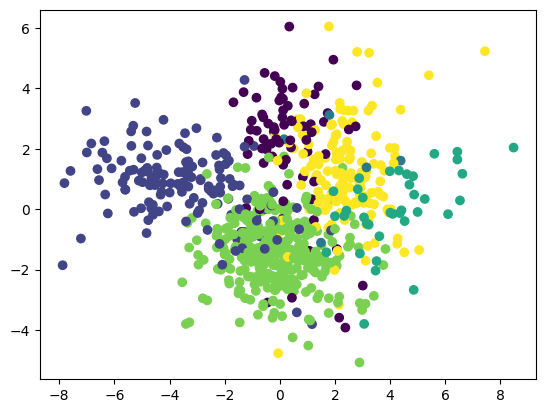

In [142]:
X = exp_latent_mean
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,2], c=(batch[1].numpy()/6))
plt.show()

In [71]:
train_full_loader = torch.utils.data.DataLoader(
        train_dst,
        batch_size=3654,
        shuffle=False,
        num_workers=cfg.dataset.num_workers,
        drop_last=False,
    )
batch_t = next(iter(train_full_loader))
input_data_t = batch_t[0] # dictionary of modalities
exp_data_t = batch_t[0]["exp"] # expression data
feat_data_t = batch_t[0]["feat"] # feature data
labels_t = batch_t[1] # tensor of labels

In [81]:
batch_out_t = model.forward(batch_t)
exp_out_t = batch_out_t[0]["exp"][0].detach().numpy()
feat_out_t = batch_out_t[0]["feat"][0].detach().numpy()
exp_latent_mean_t = batch_out_t[1]["exp"][0].detach().numpy()
exp_latent_logvar_t = batch_out_t[1]["exp"][1].detach().numpy()
feat_latent_mean_t = batch_out_t[1]["feat"][0].detach().numpy()
feat_latent_logvar_t = batch_out_t[1]["feat"][1].detach().numpy()

In [11]:
import pandas as pd
X_pca_pd = pd.DataFrame(X_pca)

In [17]:
import numpy as np

In [82]:
var_corr = np.diag(np.corrcoef(exp_data_t, exp_out_t, rowvar=False)[0:1302,1302:2604])

In [83]:
var_corr.mean()

0.2479286393236393

In [74]:
exp_data_t.var(axis=0)

tensor([1.0268, 0.9219, 1.1911,  ..., 1.0401, 1.0448, 0.6947])

In [62]:
exp_csv = pd.read_csv("./data/scMNC/expression_data.csv")

In [77]:
exp_csv.var()

Cbln2      1.000274
Enc1       1.000274
Tespa1     1.000274
Lrrtm4     1.000274
Pdzd2      1.000274
             ...   
Plch1      1.000274
Wls        1.000274
Dapk1      1.000274
Ppm1k      1.000274
Ankrd36    1.000274
Length: 1302, dtype: float64

In [76]:
exp_data_t.var(axis=0)

tensor([1.0268, 0.9219, 1.1911,  ..., 1.0401, 1.0448, 0.6947])

In [52]:
var_corr = np.diag(np.corrcoef(exp_data_t, exp_data, rowvar=False)[0:1302,1302:2604])

In [58]:

[(sum(labels_t==i) / ,sum(labels_t==i) /731 )]

tensor(247)

In [75]:
exp_data.var(axis=0)

tensor([0.8954, 1.3103, 0.2374,  ..., 0.8387, 0.8235, 2.2229])

# Reload a model

Load in the dataset of interest

In [ ]:
eval_dst = scMNC(cfg.dataset.dir_data, cfg.model.seed, train=False)                                                            
val_loader = torch.utils.data.DataLoader(
        eval_dst,
        batch_size=731,
        shuffle=False,
        num_workers=cfg.dataset.num_workers,
        drop_last=True,
    )
batch = next(iter(val_loader))
input_data = batch[0] # dictionary of modalities
exp_data = batch[0]["exp"] # expression data
feat_data = batch[0]["feat"] # feature data
labels = batch[1] # tensor of labels

Load the config file (need to figure out how to set the path when runnning the model).

In [117]:
# Open and read the YAML file
with open('run_scMNC/logs/wandb/run-20260206_110957-wuakwng2/files/config.yaml', 'r') as file:
    config = yaml.safe_load(file)
model_cfg = eval(config['cfg']['value'])

class Struct:
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            if isinstance(value, dict):
                self.__dict__[key] = Struct(**value)
            else:
                self.__dict__[key] = value

config = Struct(**model_cfg)
config.model.device="cpu"

In [128]:
checkpoint = "./run_scMNC/logs/mvvae_scMNC/wuakwng2/checkpoints/epoch=10-step=1001.ckpt"
jpvae_scmnc_model = MVJointPriorVAE.load_from_checkpoint(checkpoint, cfg=config)
jpvae_scmnc_model.eval()

MVJointPriorVAE(
  (encoders): ModuleList(
    (0): scEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=1302, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=512, bias=True)
        (3): ReLU()
        (4): Linear(in_features=512, out_features=256, bias=True)
        (5): ReLU()
      )
      (mu): Linear(in_features=256, out_features=256, bias=True)
      (logvar): Linear(in_features=256, out_features=256, bias=True)
    )
    (1): scEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=39, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=512, bias=True)
        (3): ReLU()
        (4): Linear(in_features=512, out_features=256, bias=True)
        (5): ReLU()
      )
      (mu): Linear(in_features=256, out_features=256, bias=True)
      (logvar): Linear(in_features=256, out_features=256, bias=True)
    )
  )
  (decoders): ModuleList(
    (0): scDecode

In [130]:
batch_out = jpvae_scmnc_model.forward(batch)
exp_out = batch_out[0]["exp"][0]
feat_out = batch_out[0]["feat"][0]
exp_latent_mean = batch_out[1]["exp"][0]
exp_latent_logvar = batch_out[1]["exp"][1]
feat_latent_mean = batch_out[1]["feat"][0]
feat_latent_logvar = batch_out[1]["feat"][1]

In [143]:
import umap
mapper = umap.UMAP().fit(exp_latent_mean)

ModuleNotFoundError: No module named 'umap'

# preprocessing 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn import preprocessing

In [2]:
df = pd.read_csv('data/scMNC/efeature_filtered.csv')

In [5]:
data_folder = "data/scMNC/"
data1 = pd.read_csv(data_folder + "geneExp_filtered.csv")
data2 = pd.read_csv(data_folder + "efeature_filtered.csv")
sample_names1 = data1.columns[1:]
sample_names2 = np.array(data2)[:, 0]
feature_names1 = data1.iloc[:,0]
feature_names2 = data2.columns[3:]
assert (sample_names1 == sample_names2).all()

In [6]:
data1 = np.transpose(np.array(data1)[:, 1:])
data2 = np.array(data2)[:, 3:]

In [7]:
meta = pd.read_csv(data_folder + "20200711_patchseq_metadata_mouse.csv")
meta_names = np.array(meta.columns)
meta_sid = np.argwhere(meta_names == 'transcriptomics_sample_id')[0][0]
meta_ttype = np.argwhere(meta_names == 't_type')[0][0]
meta = np.array(meta)
meta_idx = [np.argwhere(meta[:, meta_sid] == sample_names1[i])[0][0] for i in range(sample_names1.shape[0])]
type1 = type2 = np.array([x.split(' ')[0] for x in meta[meta_idx, meta_ttype]])

In [8]:
labels = [type1, type2]
features = [np.array(feature_names1), np.array(feature_names2)]
feature_dict = {'upstroke_downstroke_ratio_short_square': 'up-downstroke_ratio_short_square', 'upstroke_downstroke_ratio_long_square': 'up-downstroke_ratio_long_square'}

In [24]:
# Preprocessing
data1 = preprocessing.scale(data1, axis=0)
data2 = preprocessing.scale(data2, axis=0)
data1[np.isnan(data1)] = 0  # Replace NaN with average
data2[np.isnan(data2)] = 0
dataset = [data1, data2]

# Replace NULL feature names
for i in range(len(features)):
    if features[i] is None:
        features[i] = np.array([f'Feature {i}' for i in range(dataset[i].shape[1])])

In [26]:
labels

[array(['Sst', 'Sst', 'Sst', ..., 'Pvalb', 'Pvalb', 'Pvalb'], dtype='<U8'),
 array(['Sst', 'Sst', 'Sst', ..., 'Pvalb', 'Pvalb', 'Pvalb'], dtype='<U8')]

In [28]:
features

[array(['Cbln2', 'Enc1', 'Tespa1', ..., 'Dapk1', 'Ppm1k', 'Ankrd36'],
       dtype=object),
 array(['vrest', 'ri', 'sag', 'tau', 'vm_for_sag', 'f_i_curve_slope',
        'adaptation', 'latency', 'avg_isi',
        'upstroke_downstroke_ratio_long_square', 'peak_v_long_square',
        'peak_t_long_square', 'trough_v_long_square',
        'trough_t_long_square', 'fast_trough_v_long_square',
        'fast_trough_t_long_square', 'threshold_v_long_square',
        'threshold_i_long_square', 'threshold_t_long_square',
        'upstroke_downstroke_ratio_ramp', 'peak_v_ramp', 'peak_t_ramp',
        'trough_v_ramp', 'trough_t_ramp', 'fast_trough_v_ramp',
        'fast_trough_t_ramp', 'threshold_v_ramp', 'threshold_i_ramp',
        'threshold_t_ramp', 'upstroke_downstroke_ratio_short_square',
        'peak_v_short_square', 'peak_t_short_square',
        'trough_v_short_square', 'trough_t_short_square',
        'fast_trough_v_short_square', 'fast_trough_t_short_square',
        'threshold_v_short

In [17]:
df2 = pd.read_csv('data/scMNC/geneExp_filtered.csv')
df2.head()

,gene,PS0817_E1-50_S19,PS0817_E1-50_S26,PS0817_E1-50_S27,PS0817_E1-50_S28,PS0817_E1-50_S46,PS0817_E1-50_S52,PS0830_E1-50_S17,PS0830_E1-50_S26,PS0830_E1-50_S70,...,SM-J39TJ_S280_E1-50,SM-J39TJ_S281_E1-50,SM-J39TJ_S285_E1-50,SM-J39TJ_S287_E1-50,SM-J39T2_S314_E1-50,SM-J39S6_S190_E1-50,SM-J3A1L_S592_E1-50,SM-J3A1L_S593_E1-50,SM-J3A1L_S603_E1-50,SM-J3A1L_S604_E1-50
0,Cbln2,0,0,0,0,0,0,0,193,0,...,1,27,0,0,0,0,0,0,0,5
1,Enc1,0,11,0,0,0,0,0,4,0,...,13,25,0,21,17,0,0,0,6,0
2,Tespa1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Lrrtm4,12,0,267,1005,115,31,1174,287,2349,...,54,212,369,284,248,138,544,679,54,16
4,Pdzd2,0,0,31,1,17,1,42,3,1,...,0,19,1,22,0,0,1,10,0,17


In [25]:
df2.set_index("gene", inplace=True)

In [31]:
df_gene = df2.transpose()
df_gene.head()

gene,Cbln2,Enc1,Tespa1,Lrrtm4,Pdzd2,Fam19a1,Hs6st3,Dgkb,Hpcal1,Mlip,...,Odf2l,Maged1,Mafb,Maf,Rab3b,Plch1,Wls,Dapk1,Ppm1k,Ankrd36
PS0817_E1-50_S19,0,0,0,12,0,0,1,2,0,0,...,0,728,417,0,537,0,0,0,0,0
PS0817_E1-50_S26,0,11,0,0,0,0,0,0,0,0,...,23,520,139,0,167,0,110,149,43,0
PS0817_E1-50_S27,0,0,0,267,31,0,3,0,0,0,...,0,665,6,17,99,0,0,38,0,0
PS0817_E1-50_S28,0,0,0,1005,1,0,1,1,0,0,...,0,110,58,0,530,0,25,56,0,0
PS0817_E1-50_S46,0,0,0,115,17,0,0,64,0,0,...,4,398,0,3,231,0,0,10,0,0


In [43]:
print(df_gene.shape)
print(df.shape)
df_gene.index.intersection(df.index)

(3654, 1302)
(3654, 41)


Index(['PS0817_E1-50_S19', 'PS0817_E1-50_S26', 'PS0817_E1-50_S27',
       'PS0817_E1-50_S28', 'PS0817_E1-50_S46', 'PS0817_E1-50_S52',
       'PS0830_E1-50_S17', 'PS0830_E1-50_S26', 'PS0830_E1-50_S70',
       'PS0830_E1-50_S83',
       ...
       'SM-J39TJ_S280_E1-50', 'SM-J39TJ_S281_E1-50', 'SM-J39TJ_S285_E1-50',
       'SM-J39TJ_S287_E1-50', 'SM-J39T2_S314_E1-50', 'SM-J39S6_S190_E1-50',
       'SM-J3A1L_S592_E1-50', 'SM-J3A1L_S593_E1-50', 'SM-J3A1L_S603_E1-50',
       'SM-J3A1L_S604_E1-50'],
      dtype='object', length=3654)

In [49]:
X_train, X_test = train_test_split(df.index, test_size=0.2)